In [247]:
# System and file handling
import os
from glob import glob
import random

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2

from ultralytics import YOLO

In [248]:
class CFG:
    # DEBUG = False
    DEBUG = True
    FRACTION = 0.05 if DEBUG else 1.0
    SEED = 42

    # classes
    # Class map from dataset description
    PPE_CLASSES = {
        0: "Hardhat",
        1: "Mask",
        2: "NO-Hardhat",
        3: "NO-Mask",
        4: "NO-Safety Vest",
        5: "Person",
        6: "Safety Cone",
        7: "Safety Vest",
        8: "Machinery",
        9: "Vehicle"
    }

    # paths
    DATASET_PATHS = [
        'archive\\data\\train\\images',
        'archive\\data\\val\\images',
        'archive\\data\\test\\images'
    ]

    MODEL_PATH = "best.pt"


In [249]:
# Load images from train, val, and test sets
image_paths = []
for path in CFG.DATASET_PATHS:
    image_paths.extend(glob(os.path.join(path, "*.jpg")))

# Ensure reproducibility
random.seed(CFG.SEED)

# Shuffle image list for randomness
random.shuffle(image_paths)

# Limit number of images based on FRACTION
num_images = int(len(image_paths) * CFG.FRACTION)
image_paths = image_paths[:max(1, num_images)]  # Ensure at least 1 image is selected

In [250]:
# Display some random images from the dataset
def display_images(image_paths, num=5):
    plt.figure(figsize=(15, 5))
    sample_paths = random.sample(image_paths, num)
    for i, img_path in enumerate(sample_paths):
        img = cv2.imread(img_path)[..., ::-1]  # Convert BGR to RGB
        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

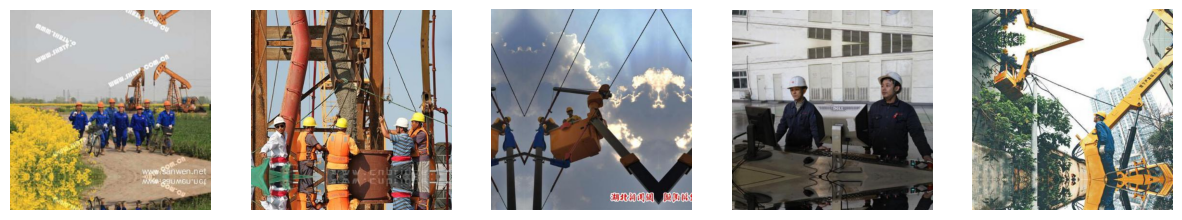

In [251]:
display_images(image_paths)

In [252]:
# Load YOLO11n model
model = YOLO(CFG.MODEL_PATH)

In [253]:
def detect_all_classes(image_paths):
    """
    Runs YOLO model on all images and stores detected objects in a DataFrame.
    Stores bounding boxes, confidence scores, and detected classes for later use.
    """
    detection_data = []

    for image_path in image_paths:
        results = model(image_path)  # Run inference

        detected_boxes = []
        detected_classes = set()  # To track unique detected classes in the image
        
        for result in results:
            for box in result.boxes:
                label = CFG.PPE_CLASSES[int(box.cls)]
                confidence = float(box.conf)
                x1, y1, x2, y2 = map(int, box.xyxy[0])  # Convert coordinates to int
                
                detected_boxes.append({"label": label, "confidence": confidence, "coords": (x1, y1, x2, y2)})
                detected_classes.add(label)

        # Store results in DataFrame
        detection_data.append({"image_path": image_path, "detected_boxes": detected_boxes, "detected_classes": list(detected_classes)})

    return pd.DataFrame(detection_data)


def filter_images(df, required_classes=[], excluded_classes=[]):
    """
    Filters images based on:
    - `required_classes`: Classes that must be present in the image.
    - `excluded_classes`: Classes that must NOT be present in the image.
    
    Returns a filtered DataFrame.
    """
    def class_filter(detected):
        detected_set = set(detected)
        return all(cls in detected_set for cls in required_classes) and not any(cls in detected_set for cls in excluded_classes)

    return df[df["detected_classes"].apply(class_filter)]


def show_random_image(df):
    """
    Randomly selects an image from the dataset and displays it with annotations.
    Uses stored detections instead of re-running the model.
    Skips drawing boxes and text for Machinery and Vehicle classes.
    """
    if df.empty:
        print("No images found matching the filter criteria.")
        return

    selected_row = df.sample(1).iloc[0]  # Select a random row
    image_path = selected_row["image_path"]
    detected_boxes = selected_row["detected_boxes"]

    # Load and process image
    img = cv2.imread(image_path)  # Read image (BGR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for visualization
    img_copy = img_rgb.copy()  # Create a copy for drawing

    for box in detected_boxes:
        x1, y1, x2, y2 = box["coords"]
        label = box["label"]
        # confidence = box["confidence"]

        # Skip drawing for Machinery and Vehicle
        if label in ["Machinery", "Vehicle"]:
            continue

        # Define colors and font properties
        # Use red for NO-Hardhat, NO-Mask, and NO-Safety Vest
        if label in ["NO-Hardhat", "NO-Mask", "NO-Safety Vest"]:
            color = (255, 0, 0)  # Red in BGR
        else:
            color = (0, 255, 0)  # Green in BGR
        
        font_scale = 0.5  # Smaller font
        thickness = 1  # Thinner text for better clarity

        # Draw bounding box
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, thickness)

        # Adjust label position
        if label in ["Machinery", "Person", "Vehicle"]:
            text_x, text_y = x1, y1  # Keep label at the top border
        else:
            text_x, text_y = x1, y1 + 15  # Shift other labels slightly below the top border

        # Define text content
        # text = f"{label} {confidence:.2f}"
        text = label
        text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_PLAIN, font_scale, thickness)[0]

        # Put label text on the image
        cv2.putText(img_copy, text, (text_x, text_y - 2), 
                    cv2.FONT_HERSHEY_PLAIN, font_scale, color, thickness)

    # Display image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_copy)
    plt.axis("off")
    plt.show()





In [254]:
# Detect all classes and store results
df_detections = detect_all_classes(image_paths)


image 1/1 d:\Mode Nartec\second\archive\data\test\images\006073_jpg.rf.312319df30ba3f6a786b684edb9670b7.jpg: 640x640 10 Hardhats, 11 NO-Masks, 8 NO-Safety Vests, 10 Persons, 273.1ms
Speed: 9.5ms preprocess, 273.1ms inference, 5.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Mode Nartec\second\archive\data\val\images\002131_jpg.rf.0bbe866180d2e535484c3760c609cf0c.jpg: 640x640 1 Hardhat, 4 NO-Safety Vests, 5 Persons, 211.9ms
Speed: 11.4ms preprocess, 211.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Mode Nartec\second\archive\data\test\images\006336_jpg.rf.7996cb054fd13f2b5fa79dcb24a8349d.jpg: 640x640 5 Hardhats, 2 NO-Masks, 4 NO-Safety Vests, 5 Persons, 183.7ms
Speed: 9.9ms preprocess, 183.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 d:\Mode Nartec\second\archive\data\val\images\002281_jpg.rf.cab5f32bb62cc5ea42e53f177b38304e.jpg: 640x640 1 Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 181.7ms
S

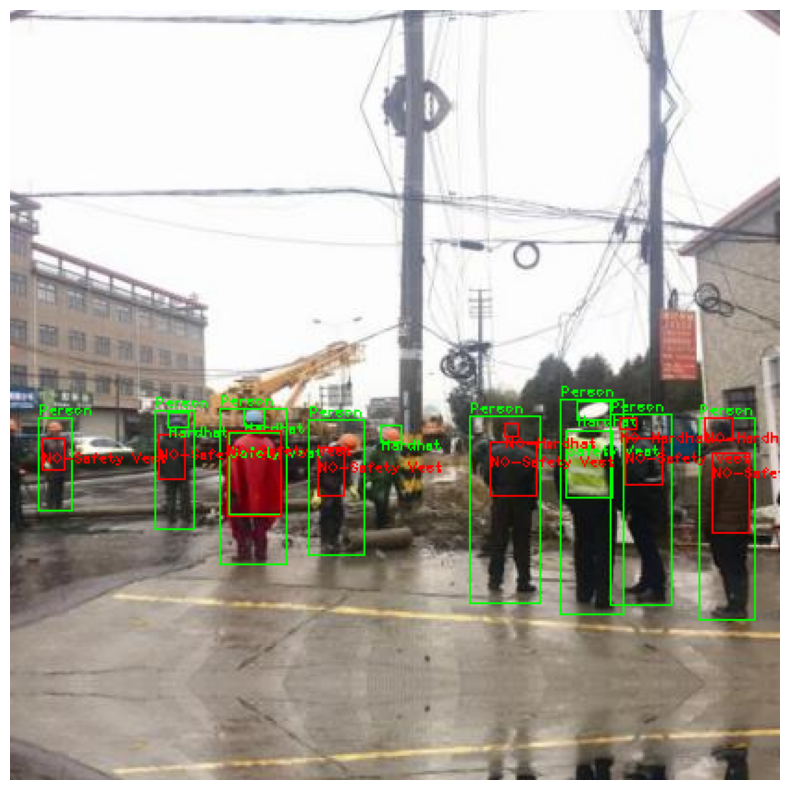

In [255]:
show_random_image(df_detections)

In [256]:
# Filter images with only 'Person' or 'Person' + 'NO-Hardhat'
df_filtered = filter_images(df_detections, required_classes=["Person"], excluded_classes=["Hardhat", "Mask", "Safety Vest"])

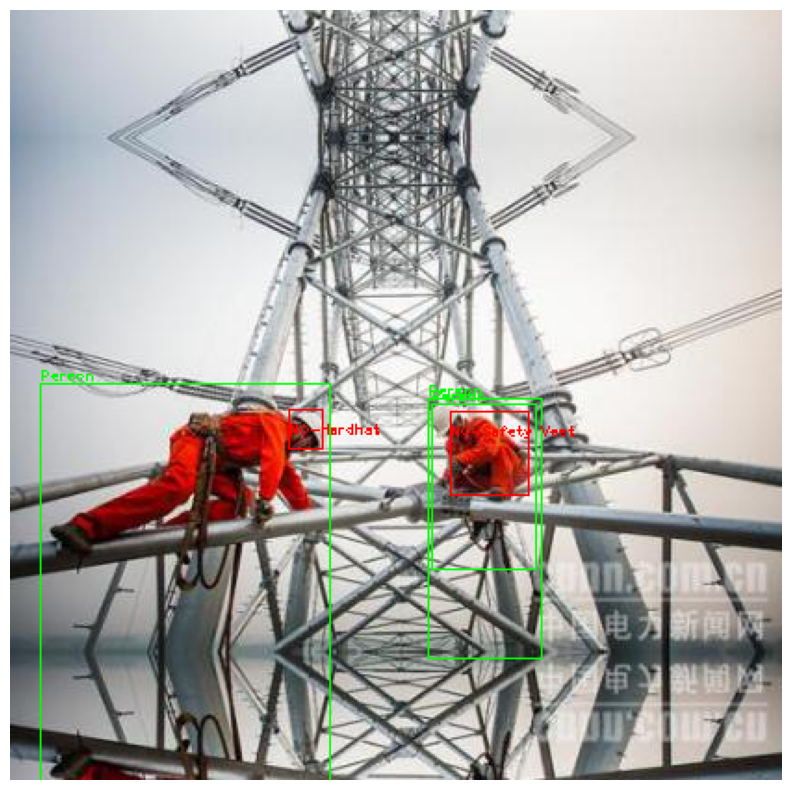

In [264]:
show_random_image(df_filtered)